# 01 - Exploratory data analysis
UCI Heart Disease (Cleveland, Hungary, Switzerland, VA Long Beach), 920 patients.

In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from src.preprocess import load_data
sns.set_theme(style='whitegrid')
df = load_data('../data/heart_disease_uci.csv')
df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 1. Target
Original `num` is 0-4 (severity). We use `target = num > 0`.

target
1    0.553
0    0.447
Name: proportion, dtype: float64


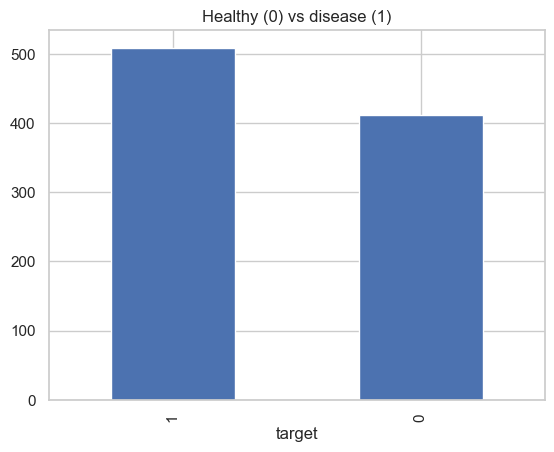

In [2]:
print(df['target'].value_counts(normalize=True).round(3))
df['target'].value_counts().plot.bar(title='Healthy (0) vs disease (1)');

## 2. Missing values
`chol` and `trestbps` zeros were converted to NaN (impossible values).

ca          0.664
thal        0.528
slope       0.336
chol        0.220
fbs         0.098
oldpeak     0.067
trestbps    0.065
thalch      0.060
exang       0.060
restecg     0.002
dtype: float64

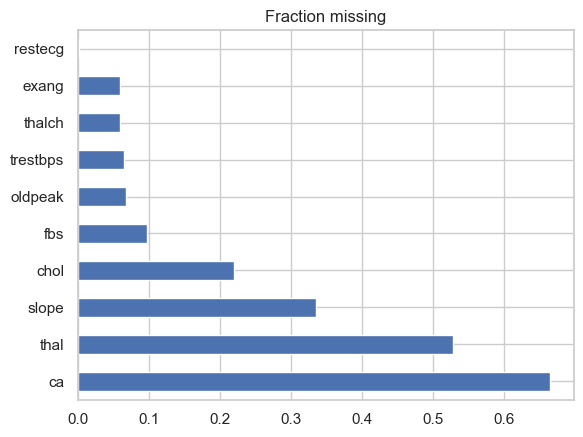

In [3]:
miss = df.isna().mean().sort_values(ascending=False)
miss[miss > 0].plot.barh(title='Fraction missing');
miss[miss > 0].round(3)

## 3. Missingness depends on the hospital
`ca` is almost only recorded at Cleveland; Switzerland has no cholesterol at all. Missingness therefore leaks *which hospital* a patient came from, and hospitals have very different disease rates, so the model should not be allowed to learn from it blindly. This is why the hospital column is never a feature and why `train.py` compares dropping vs keeping `ca`/`thal`/`slope`.

In [4]:
by_site = df.groupby('dataset').agg(n=('target','size'), disease_rate=('target','mean'),
        ca_missing=('ca', lambda s: s.isna().mean()), thal_missing=('thal', lambda s: s.isna().mean()),
        chol_missing=('chol', lambda s: s.isna().mean())).round(2)
by_site

,n,disease_rate,ca_missing,thal_missing,chol_missing
dataset,,,,,
Cleveland,304,0.46,0.02,0.01,0.00
Hungary,293,0.36,0.99,0.90,0.08
Switzerland,123,0.93,0.96,0.42,1.00
VA Long Beach,200,0.74,0.99,0.83,0.28


## 4. Numeric features vs target

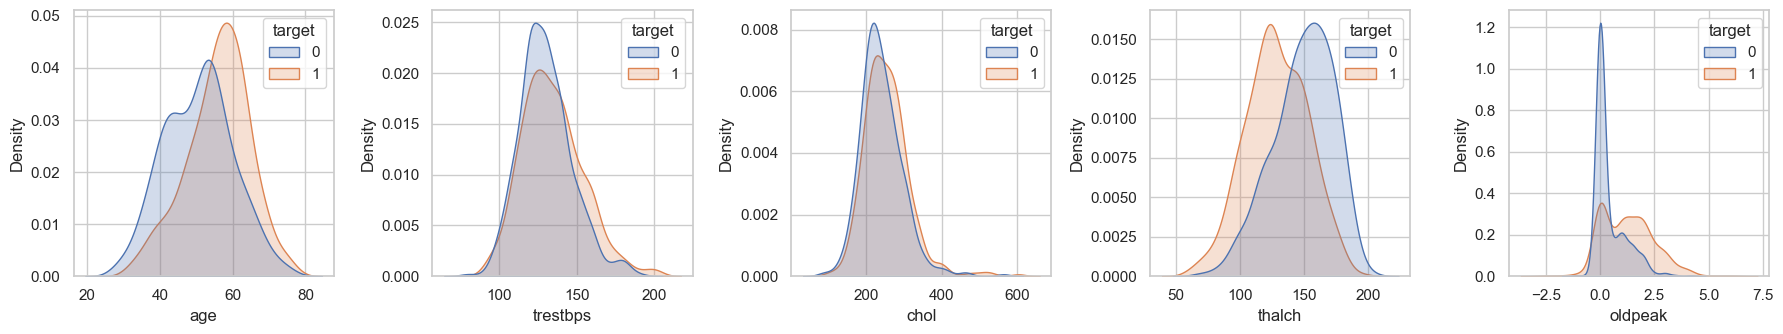

In [5]:
num = ['age','trestbps','chol','thalch','oldpeak']
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
for ax, c in zip(axes, num):
    sns.kdeplot(data=df, x=c, hue='target', common_norm=False, fill=True, ax=ax)
fig.tight_layout()

## 5. Categorical features vs disease rate

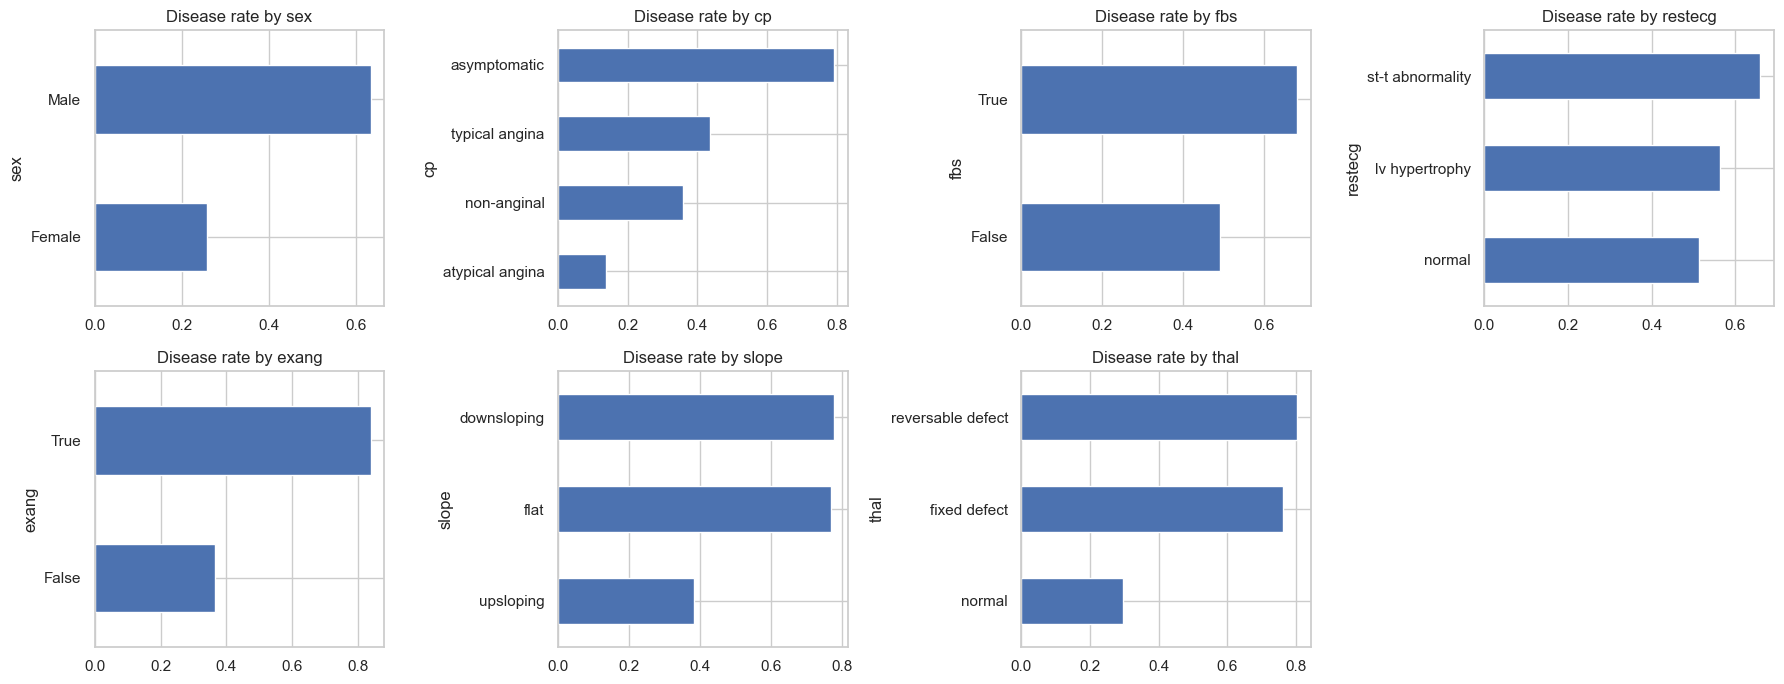

In [6]:
cats = ['sex','cp','fbs','restecg','exang','slope','thal']
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, c in zip(axes.ravel(), cats):
    df.groupby(c)['target'].mean().sort_values().plot.barh(ax=ax, title=f'Disease rate by {c}')
axes.ravel()[-1].axis('off'); fig.tight_layout()

Chest pain type is striking: **asymptomatic** patients (no chest pain) have the highest disease rate. Men have a much higher rate than women, partly because women are under-represented here.